# 03 · Results and the verdict

All numbers here are read from `models/metrics.json`, which `python -m weather_edge report` builds from the committed reports, so this notebook needs no data. The figures are the ones in `reports/figures/`; the tables give the intervals behind them.

In [1]:
import os, json
os.chdir(next(p for p in [os.getcwd(), os.path.dirname(os.getcwd())] if os.path.exists(os.path.join(p, "pyproject.toml"))))
import duckdb, numpy as np, pandas as pd, matplotlib.pyplot as plt
from weather_edge import plots
from weather_edge.plots import read_tables, SERIES, INK, INK_2, GRID, SURFACE
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID, "axes.spines.top": False, "axes.spines.right": False, "axes.titlelocation": "left", "figure.dpi": 110})
pd.set_option("display.width", 160)
from IPython.display import Image, display
metrics = json.load(open("models/metrics.json"))
print(metrics["verdict"])

No tradeable edge demonstrated: the model beats the market on probability only two days out (2025-01 to 2026-07), that edge is not positive at conservative fills and does not hold on the 2026-08 to 09 holdout.


## 1. Model against market, eight cities at noon

Market minus model Brier on the buckets where the two disagree by 10c or more; positive means the model is better; 90% day-bootstrap intervals.

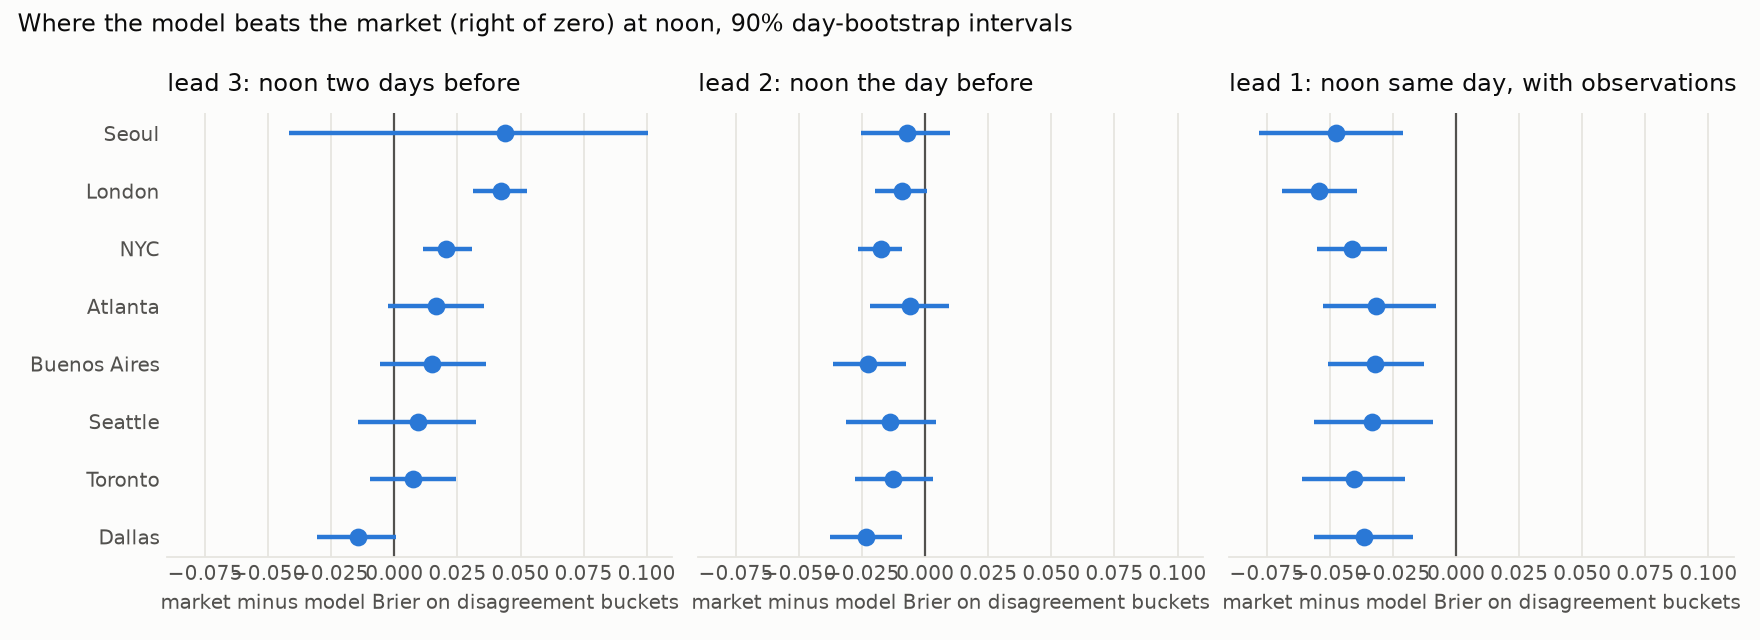

,lead1_obs,lead2_emos,lead3_emos
city,,,
London,"-0.054 (-0.069, -0.039)","-0.009 (-0.020, +0.001)","+0.042 (+0.031, +0.052)"
NYC,"-0.041 (-0.055, -0.027)","-0.018 (-0.027, -0.009)","+0.021 (+0.011, +0.031)"
Dallas,"-0.036 (-0.056, -0.017)","-0.023 (-0.038, -0.009)","-0.014 (-0.031, +0.001)"
Seoul,"-0.048 (-0.078, -0.021)","-0.007 (-0.025, +0.010)","+0.044 (-0.042, +0.100)"
Toronto,"-0.041 (-0.061, -0.020)","-0.013 (-0.028, +0.003)","+0.007 (-0.009, +0.025)"
Atlanta,"-0.032 (-0.053, -0.008)","-0.006 (-0.022, +0.009)","+0.016 (-0.003, +0.036)"
Seattle,"-0.033 (-0.057, -0.009)","-0.014 (-0.031, +0.004)","+0.009 (-0.015, +0.032)"
Buenos Aires,"-0.032 (-0.051, -0.013)","-0.023 (-0.037, -0.008)","+0.015 (-0.006, +0.036)"


In [2]:
display(Image("reports/figures/model_vs_market.png"))
rows = [{"city": plots.STATION_NAMES[st], **{k: f"{v['diff']:+.3f} ({v['ci_low']:+.3f}, {v['ci_high']:+.3f})" for k, v in d.items() if k in ("lead3_emos", "lead2_emos", "lead1_obs")}} for st, d in metrics["model_vs_market_noon"].items()]
pd.DataFrame(rows).set_index("city")

## 2. NYC by decision hour

Earlier decisions face thinner books and a larger two-days-out edge; the same-day gap is the same at every hour from 06:00.

In [3]:
pd.DataFrame({h: {k: f"{v['diff']:+.3f}" for k, v in d.items()} for h, d in metrics["nyc_by_decision_hour"].items()}).T

,lead1_clim,lead1_raw,lead1_emos,lead1_obs,lead2_clim,lead2_raw,lead2_emos,lead3_clim,lead3_raw,lead3_emos
06:00,-0.154,-0.057,-0.050,-0.043,-0.103,-0.024,-0.011,-0.042,+0.031,+0.037
08:00,-0.159,-0.061,-0.054,-0.044,-0.107,-0.027,-0.016,-0.054,+0.017,+0.033
10:00,-0.163,-0.062,-0.054,-0.045,-0.109,-0.028,-0.018,-0.067,+0.006,+0.017
12:00,-0.175,-0.068,-0.062,-0.041,-0.112,-0.030,-0.018,-0.068,+0.008,+0.021


## 3. The tape backtest

Maker orders at 10c of edge, 5 shares, resting 24 h; fills inferred from taker prints: `touch` at or through the price, `through` strictly beyond it (the level was cleared), `*_haircut` with winning fills halved.

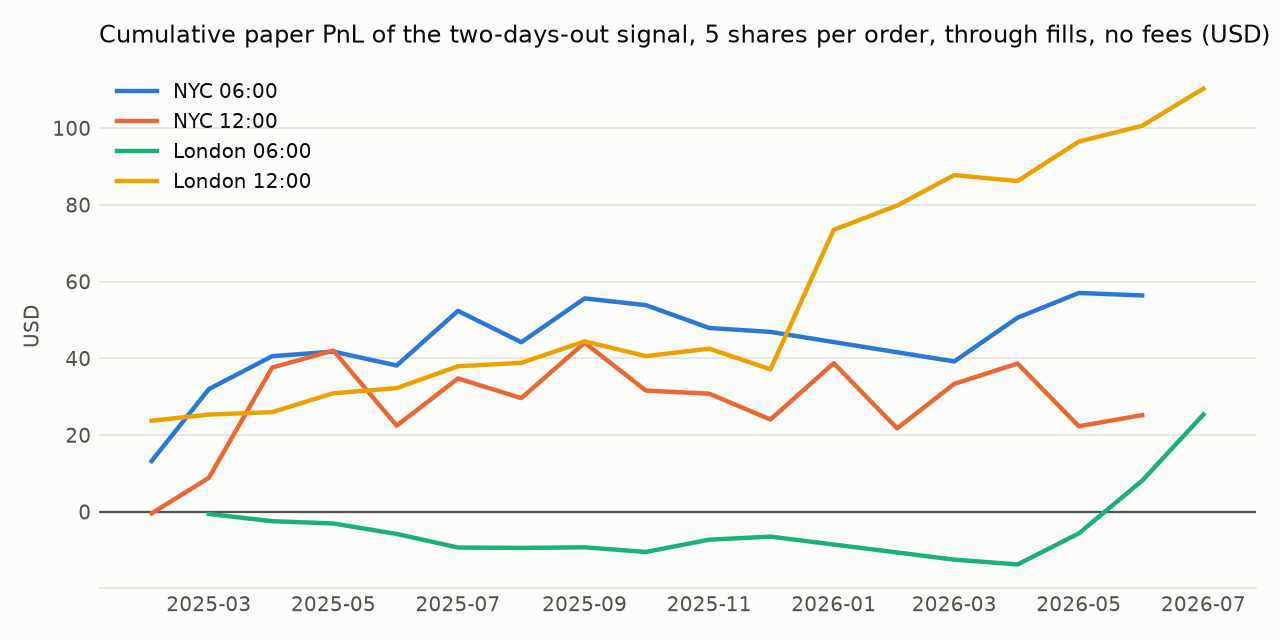

"c per share (90% interval of PnL per order, USD)",touch,through,touch_haircut,through_haircut
KLGA_06,"+4.4c (+0.00, +0.43)","+4.3c (-0.00, +0.44)","-8.5c (-0.45, -0.12)","-8.6c (-0.45, -0.12)"
KLGA_12,"+1.9c (-0.07, +0.25)","+0.9c (-0.11, +0.20)","-10.6c (-0.49, -0.24)","-11.6c (-0.53, -0.28)"
EGLC_06,"+3.6c (-0.10, +0.46)","+3.2c (-0.14, +0.44)","-7.6c (-0.49, -0.06)","-7.9c (-0.51, -0.06)"
EGLC_12,"+5.7c (+0.10, +0.45)","+5.5c (+0.08, +0.45)","-6.8c (-0.36, -0.10)","-7.1c (-0.39, -0.11)"


In [4]:
display(Image("reports/figures/backtest_cumulative_pnl.png"))
bt = pd.DataFrame({k: {rule: f"{v['pnl_c_per_share']:+.1f}c ({v['pnl_usd_per_order_ci_low']:+.2f}, {v['pnl_usd_per_order_ci_high']:+.2f})" for rule, v in d.items()} for k, d in metrics["backtest_lead3"].items()}).T
bt.columns.name = "c per share (90% interval of PnL per order, USD)"; bt

## 4. The holdout, once

The configuration was frozen, then scored on August to September 2026 exactly once.

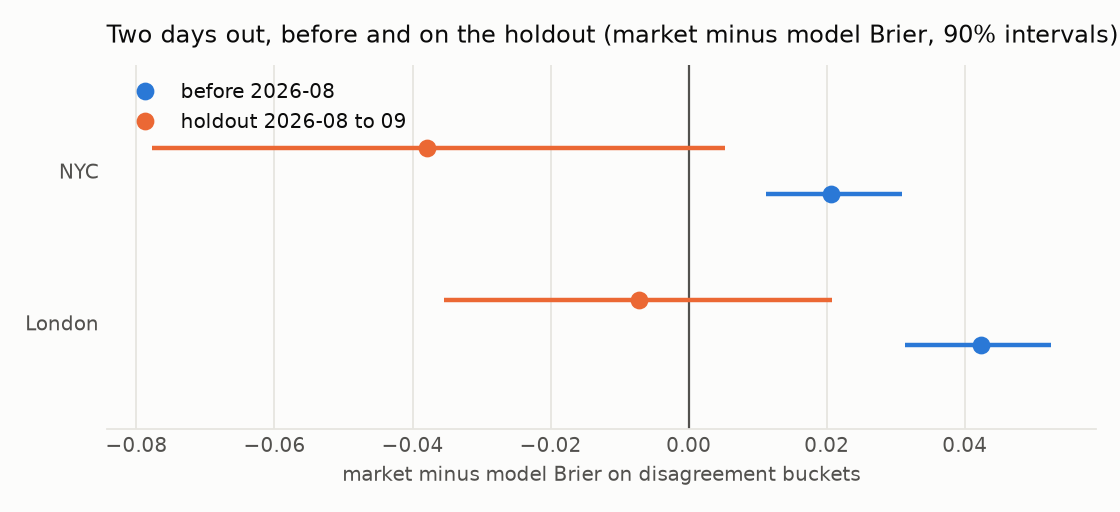

diff  ci_low  ci_high  days  buckets
station period                                                       
EGLC    holdout 2026-08 to 09 -0.0072 -0.0355   0.0207    57      627
        before 2026-08         0.0423  0.0313   0.0525   364     3111
KLGA    holdout 2026-08 to 09 -0.0379 -0.0778   0.0053    29      319
        before 2026-08         0.0206  0.0112   0.0309   408     3215

In [5]:
display(Image("reports/figures/holdout.png"))
pd.DataFrame(metrics["holdout_lead3"]).set_index(["station", "period"])

## 5. Timing

Slope of the market's implied high on the ECMWF run's change, by minutes after publication. A slope of 1 would be full pass-through; 0.05 after four hours is none.

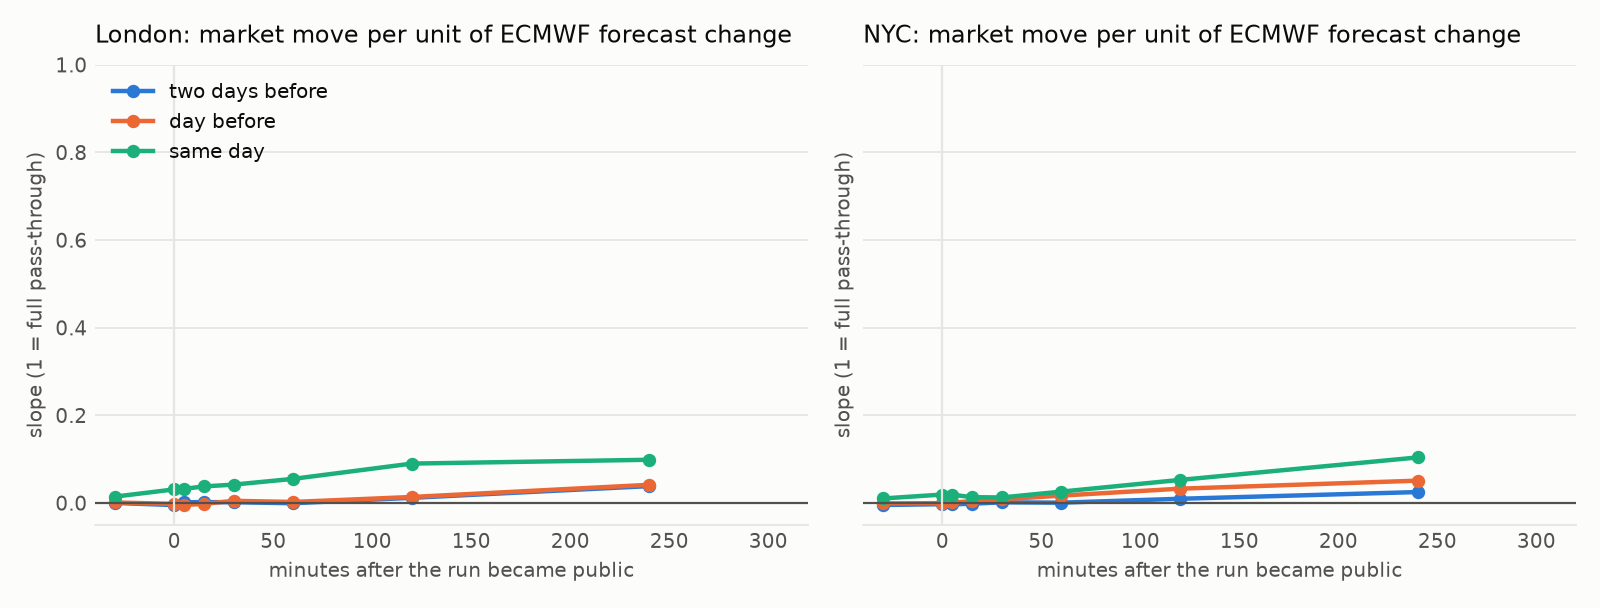

,EGLC,KLGA
day before_-30min,0.0013,-0.0009
day before_0min,-0.0021,-0.0003
day before_5min,-0.0045,0.0012
day before_15min,-0.0020,0.0041
day before_30min,0.0050,0.0083
day before_60min,0.0024,0.0169
day before_120min,0.0138,0.0327
day before_240min,0.0416,0.0510
same day_-30min,0.0146,0.0104
same day_0min,0.0311,0.0193


In [6]:
display(Image("reports/figures/timing.png"))
pd.DataFrame(metrics["timing_ecmwf_slope"])

## Verdict

- Probability: the model beats the market two days out in London and NYC (intervals above zero), is level one day out, and loses on the day everywhere, even with the morning's observations.
- Economics: at conservative fills the two-days-out edge is 1 to 6c per share gross and negative with a haircut; the model expects 18 to 20c per filled share, so about 70% of the paper edge is adverse selection.
- Out of sample: the edge is absent on the holdout. The market's Brier two days out fell from 0.10 to 0.065 between 2025 and late 2026.
- Timing: prices do not react to model publications, so the market's information is not the public runs.

No live capital. The project's value is the pipeline and the documented negative.